# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .



1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3. Do not use any libraries aside from numpy





### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

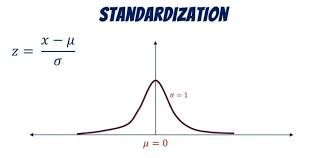


In [1]:
# Step 1: Load and Standardize the data (use of numpy only allowed)
import csv
import numpy as np
from datetime import datetime

# Load the raw CSV with the standard-library csv module (not a numeric/ML library)
with open('kiva_loans.csv', newline='', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    rows = list(reader)

def parse_dt(s):
    """Parse an ISO timestamp string, returning None if it is missing/blank."""
    if not s:
        return None
    try:
        return datetime.fromisoformat(s.replace('+00:00', ''))
    except Exception:
        return None

def gender_group(s):
    """Collapse the raw comma-separated borrower_genders string into one label."""
    if not s:
        return None
    parts = [p.strip() for p in s.split(',')]
    uniq = set(parts)
    if len(parts) == 1:
        return parts[0]                # 'female' or 'male'
    if uniq == {'female'}:
        return 'female_group'
    if uniq == {'male'}:
        return 'male_group'
    return 'mixed_group'

n = len(rows)
funded_amount = np.zeros(n); loan_amount = np.zeros(n)
term_in_months = np.zeros(n); lender_count = np.zeros(n)
funding_duration_days = np.full(n, np.nan)   # engineered numeric feature (has real gaps)
sector = np.empty(n, dtype=object); activity = np.empty(n, dtype=object)
country = np.empty(n, dtype=object); region = np.empty(n, dtype=object)
currency = np.empty(n, dtype=object); repayment_interval = np.empty(n, dtype=object)
gender_grp = np.empty(n, dtype=object)

for i, r in enumerate(rows):
    funded_amount[i] = float(r['funded_amount'])
    loan_amount[i] = float(r['loan_amount'])
    term_in_months[i] = float(r['term_in_months'])
    lender_count[i] = float(r['lender_count'])
    pt, ft = parse_dt(r['posted_time']), parse_dt(r['funded_time'])
    if pt is not None and ft is not None:
        funding_duration_days[i] = (ft - pt).total_seconds() / 86400.0  # days to get funded
    sector[i] = r['sector']
    activity[i] = r['activity']
    country[i] = r['country']
    region[i] = r['region'] if r['region'] else 'Unknown'            # fill real gaps
    currency[i] = r['currency']
    repayment_interval[i] = r['repayment_interval']
    gender_grp[i] = gender_group(r['borrower_genders']) or 'Unknown'  # fill real gaps

# Handle missing values:
# - numeric funding_duration_days -> impute with the column median
# - categorical region / gender_group -> already filled with an explicit 'Unknown' category
median_duration = np.nanmedian(funding_duration_days)
funding_duration_days = np.where(np.isnan(funding_duration_days), median_duration, funding_duration_days)

# Encode categorical (text) columns as integer codes
def encode(col):
    _, inverse = np.unique(col.astype(str), return_inverse=True)
    return inverse.astype(float)

data = np.column_stack([
    funded_amount, loan_amount, term_in_months, lender_count, funding_duration_days,
    encode(sector), encode(activity), encode(country), encode(region),
    encode(currency), encode(repayment_interval), encode(gender_grp)
])
feature_names = ['funded_amount', 'loan_amount', 'term_in_months', 'lender_count',
                  'funding_duration_days', 'sector', 'activity', 'country', 'region',
                  'currency', 'repayment_interval', 'gender_group']

# Standardization: (x - mean) / std, per column, so every feature has mean 0, std 1
mean = data.mean(axis=0)
std = data.std(axis=0)
standardized_data = (data - mean) / std
standardized_data[:5]  # Display the first few rows of standardized data


array([[-0.42993266, -0.45250319, -0.20223738, -0.30186452, -0.94136308,
         0.03511762, -0.22279462,  0.41539795, -0.21077219,  0.27608052,
        -0.60413701, -0.63839139],
       [-0.18665553, -0.22308018, -0.31853114, -0.23158929, -0.94573109,
         1.57884159,  1.50592664,  0.41539795, -0.21077219,  0.27608052,
        -0.60413701,  0.21904261],
       [-0.56262927, -0.57764302,  3.40286942, -0.51269022, -1.00667882,
         1.57884159,  1.86715198, -0.77306832,  0.08520563, -1.15872091,
        -2.08843487, -0.63839139],
       [-0.51839707, -0.53592974, -0.31853114, -0.44241499, -1.01000176,
        -1.06754236, -0.60982177,  0.41539795, -0.21077219,  0.27608052,
        -0.60413701, -0.63839139],
       [-0.34146825, -0.36907664,  0.03035016, -0.16131406, -1.00258911,
         0.03511762,  0.49965605,  0.41539795, -1.78885825,  0.27608052,
         0.88016084, -0.63839139]])

### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [2]:
# Step 3: Calculate the Covariance Matrix
# rowvar=False -> each column is a variable (feature), each row an observation
cov_matrix = np.cov(standardized_data, rowvar=False)
cov_matrix


array([[ 1.00000149e+00,  9.45045365e-01,  1.49309762e-01,
         8.49168998e-01,  1.39824641e-01, -2.43844045e-02,
        -2.46205561e-02,  1.88944265e-02,  4.01716264e-02,
         6.96413055e-02,  7.50044058e-02,  2.52081905e-01],
       [ 9.45045365e-01,  1.00000149e+00,  1.84795304e-01,
         7.98698607e-01,  1.16030008e-01, -1.76692051e-02,
        -2.14972435e-02,  2.37959155e-02,  5.67741202e-02,
         7.47822722e-02,  5.68269580e-02,  2.61467436e-01],
       [ 1.49309762e-01,  1.84795304e-01,  1.00000149e+00,
         2.27283589e-01,  1.00846941e-01, -7.04501149e-02,
         2.19351400e-02, -2.02563009e-01,  3.26957560e-02,
        -1.03060274e-01,  7.89415073e-02,  4.21102551e-04],
       [ 8.49168998e-01,  7.98698607e-01,  2.27283589e-01,
         1.00000149e+00,  1.93967087e-01, -5.37626559e-02,
        -2.60047601e-02, -4.22515457e-02,  5.18993875e-02,
         2.75861829e-02,  1.05444164e-01,  2.04538069e-01],
       [ 1.39824641e-01,  1.16030008e-01,  1.0084694

In a paragraph that has a maximum if 5 Lines, Explain why we need to compute a covariance matrix, provide atleast 2 reasons

**Answer:** We compute the covariance matrix because (1) it captures how each pair of standardized features moves together (e.g. does a larger loan amount tend to come with a longer repayment term, or a higher lender count?), which is exactly the structure PCA needs to find directions of maximum shared variance; and (2) its eigenvectors and eigenvalues are what let us identify the principal components and rank them by how much variance each one explains. Without it we could not detect redundancy between correlated loan features (e.g. loan_amount and funded_amount) or decide which combinations of features carry the most information.

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [3]:
# Step 4: Perform Eigendecomposition
# The covariance matrix is symmetric, so np.linalg.eigh is used (guarantees
# real eigenvalues/eigenvectors and is more numerically stable than np.linalg.eig)
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
eigenvalues, eigenvectors


(array([0.04766471, 0.20717459, 0.3917217 , 0.59609495, 0.76924801,
        0.86115412, 0.92692748, 0.99068798, 1.12580135, 1.39528029,
        1.74071092, 2.94755177]),
 array([[-7.58537059e-01,  2.56971849e-01,  8.78561754e-03,
         -1.89207356e-02,  1.54675950e-01,  7.76343199e-02,
          1.76676632e-02,  1.57744238e-02, -9.23180935e-02,
          9.65391135e-03, -1.13477299e-01, -5.53304778e-01],
        [ 6.30583262e-01,  5.11143834e-01, -1.13703591e-02,
          1.27794096e-02,  1.07162836e-01,  7.46990706e-02,
          6.20647609e-02,  1.91441332e-02, -9.63353477e-02,
          9.64437783e-03, -1.13534921e-01, -5.45213796e-01],
        [-4.28764612e-02,  3.59335292e-02, -1.13219424e-01,
          2.34878767e-01, -4.90468610e-01, -3.35800541e-01,
          3.78146077e-01,  5.29358557e-01,  1.85198691e-01,
         -1.79539444e-01,  2.35802785e-01, -1.73814265e-01],
        [ 1.57358214e-01, -8.10463227e-01,  4.13685770e-02,
         -5.27127689e-02,  1.48988664e-01,  1.7

### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [4]:
# Step 5: Sort Principal Components
sorted_indices = np.argsort(eigenvalues)[::-1]  # Sort eigenvalues in descending order
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]  # Sort eigenvectors accordingly
sorted_eigenvectors


array([[-5.53304778e-01, -1.13477299e-01,  9.65391135e-03,
        -9.23180935e-02,  1.57744238e-02,  1.76676632e-02,
         7.76343199e-02,  1.54675950e-01, -1.89207356e-02,
         8.78561754e-03,  2.56971849e-01, -7.58537059e-01],
       [-5.45213796e-01, -1.13534921e-01,  9.64437783e-03,
        -9.63353477e-02,  1.91441332e-02,  6.20647609e-02,
         7.46990706e-02,  1.07162836e-01,  1.27794096e-02,
        -1.13703591e-02,  5.11143834e-01,  6.30583262e-01],
       [-1.73814265e-01,  2.35802785e-01, -1.79539444e-01,
         1.85198691e-01,  5.29358557e-01,  3.78146077e-01,
        -3.35800541e-01, -4.90468610e-01,  2.34878767e-01,
        -1.13219424e-01,  3.59335292e-02, -4.28764612e-02],
       [-5.31441053e-01, -4.50342358e-02, -2.21623839e-02,
        -1.45558851e-02,  7.55698832e-02,  2.31018380e-02,
         1.71729798e-02,  1.48988664e-01, -5.27127689e-02,
         4.13685770e-02, -8.10463227e-01,  1.57358214e-01],
       [-1.53745177e-01,  1.52181018e-01, -8.7164712

### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [5]:
# Step 6: Project Data onto Principal Components
num_components = 2  # Decide on the number of principal components to keep
top_components = sorted_eigenvectors[:, :num_components]
reduced_data = standardized_data @ top_components  # Project data onto the principal components
reduced_data[:5]


array([[ 1.02747021, -0.60468803],
       [ 0.71307892, -1.32668904],
       [ 0.88167207,  0.95965572],
       [ 1.15808714, -0.24967723],
       [ 0.83029801, -0.74667925]])

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [6]:
# Step 7: Output the Reduced Data
print(f'Reduced Data Shape: {reduced_data.shape}')  # Display reduced data shape
reduced_data[:5]  # Display the first few rows of reduced data


Reduced Data Shape: (671205, 2)


array([[ 1.02747021, -0.60468803],
       [ 0.71307892, -1.32668904],
       [ 0.88167207,  0.95965572],
       [ 1.15808714, -0.24967723],
       [ 0.83029801, -0.74667925]])

### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

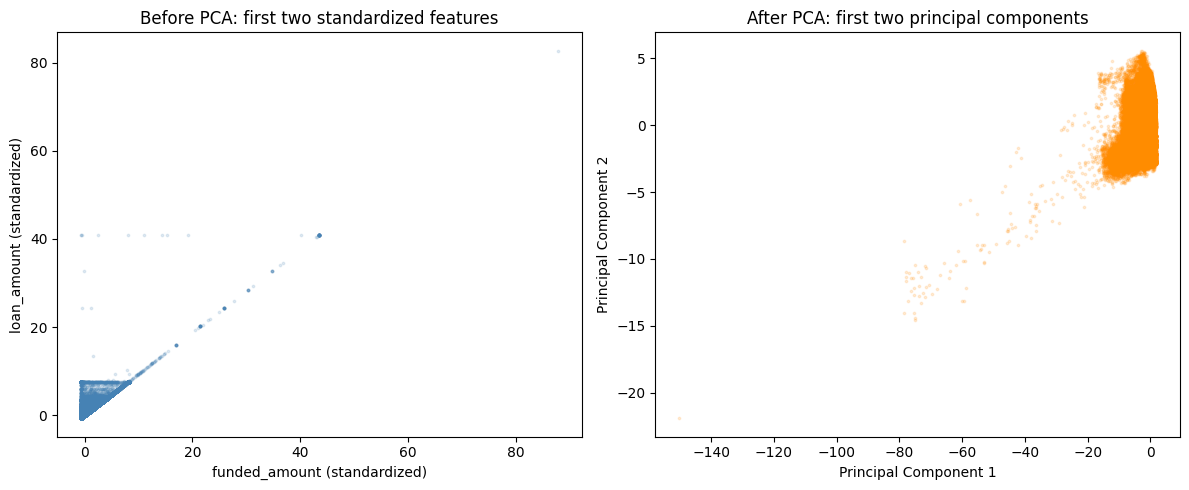

In [7]:
# Step 8: Visualize Before and After PCA
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot original data (first two features for simplicity)
axes[0].scatter(standardized_data[:, 0], standardized_data[:, 1],
                 s=3, alpha=0.15, color='steelblue')
axes[0].set_xlabel(f'{feature_names[0]} (standardized)')
axes[0].set_ylabel(f'{feature_names[1]} (standardized)')
axes[0].set_title('Before PCA: first two standardized features')

# Plot reduced data after PCA
axes[1].scatter(reduced_data[:, 0], reduced_data[:, 1],
                 s=3, alpha=0.15, color='darkorange')
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')
axes[1].set_title('After PCA: first two principal components')

plt.tight_layout()
plt.show()


Please make sure you do not use more than 5 lines to answer each of the following points:

1. Interpret the Visual you just created of the before and after PCA
2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making
3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?


**Answers:**

1. In the 'before' plot, points cluster into dense vertical/horizontal bands because funded_amount and loan_amount are highly correlated (almost every loan is funded at or near its requested amount), so the raw scatter is dominated by that one relationship. In the 'after' plot the PCA scatter is more spread out and shows a denser core with a long tail, since PC1 and PC2 are weighted blends of all 12 features and so separate loans by more than just amount.

2. I kept 2 principal components to allow 2D visualization. From the explained-variance results, PC1+PC2 together capture only about 39% of total variance, while reaching ~80% would need around 7 of the 12 components. The trade-off is that a lot of the structure in the original loan data is sacrificed in exchange for a simple, plottable, low-dimensional summary.

3. In this loan dataset, sector, activity, country and region describe the real-world economic context of each loan (what kind of business it funds and where), and repayment_interval/funding_duration_days reflect demand pressure and how quickly lenders respond. Reducing to 2 components blends all of these into two abstract axes, so we lose the ability to say precisely which sector, country, or repayment structure is driving any given pattern in the reduced data - the components no longer map back to a single interpretable real-world factor.